In [18]:
#!pip freeze > requirements.txt

In [1]:
#Orchestration by Example
#Automatic Music Orchestration
#By Gissel Velarde
#Updates
#14.8.2025
import numpy as np
import os
import pandas as pd
import sys
sys.path.append('amos') 
from midi2df2midi import midi_to_dataframe, save_midi_from_df 
from mappings import fill_quaterna_columns, learn_quaterna_mapping

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import time 

In [3]:
from sklearn.pipeline import make_pipeline
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout, LayerNormalization, MultiHeadAttention
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [4]:
#Gemini
#2.5 Flash
#Prompt: include an LSTM and a Transformer to the code pasted here:
# --- Wrapper Classes for Keras Models to be used with scikit-learn ---

class KerasClassifierWrapper:
    """
    A wrapper class to make a Keras model compatible with scikit-learn's
    pipeline and plotting functions. It handles the reshaping of 2D data
    to the 3D format required by recurrent and transformer networks.
    """
    def __init__(self, model_builder_func, **kwargs):
        self.model = None
        self.model_builder_func = model_builder_func
        self.builder_kwargs = kwargs
        self.input_shape = None
        self.classes_ = None

    def fit(self, X, y):
        # Determine the number of classes
        self.classes_ = np.unique(y)
        num_classes = len(self.classes_)

        # Reshape data for LSTM/Transformer: add a timestep dimension
        # (n_samples, n_features) -> (n_samples, 1, n_features)
        self.input_shape = (1, X.shape[1])
        X_reshaped = np.expand_dims(X, axis=1)

        # Build and compile the model
        self.model = self.model_builder_func(self.input_shape, num_classes, **self.builder_kwargs)

        # One-hot encode the labels for training
        y_one_hot = to_categorical(y, num_classes=num_classes)

        # Train the model
        self.model.fit(X_reshaped, y_one_hot, epochs=50, batch_size=32, verbose=0)
        return self

    def predict_proba(self, X):
        # Reshape the input data to match the model's expected shape
        X_reshaped = np.expand_dims(X, axis=1)
        # Get the class probabilities
        return self.model.predict(X_reshaped, verbose=0)

    def predict(self, X):
        # Predict the class with the highest probability
        return np.argmax(self.predict_proba(X), axis=1)
    
    def score(self, X, y):
        """
        Calculates the accuracy of the model on the given data.
        """
        # Reshape the input data to match the model's expected shape
        X_reshaped = np.expand_dims(X, axis=1)
        # One-hot encode the labels for evaluation
        y_one_hot = to_categorical(y, num_classes=len(self.classes_))
        # Evaluate the model on the provided data and return the accuracy
        _, accuracy = self.model.evaluate(X_reshaped, y_one_hot, verbose=0)
        return accuracy

# --- Transformer Block Definition ---

class TransformerBlock(tf.keras.layers.Layer):
    """
    A custom Keras layer for a simple Transformer block.
    This includes multi-head attention and a feed-forward network.
    """
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)
        # Save config for serialization
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.rate = rate

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super(TransformerBlock, self).get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "rate": self.rate
        })
        return config

# --- Keras Model Builders ---

def build_lstm_classifier_simple(input_shape, num_classes):
    """Builds a simple LSTM model."""
    inputs = Input(shape=input_shape)
    x = LSTM(16)(inputs)
    x = Dense(8, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model
    
def build_lstm_classifier(input_shape, num_classes):
    """
    Builds a three-layer stacked LSTM model as in (Dong, 2021)
    """
    inputs = Input(shape=input_shape)
    # First LSTM layer, returns sequences to the next layer
    x = LSTM(128, return_sequences=True)(inputs)
    # Second LSTM layer, also returns sequences
    x = LSTM(128, return_sequences=True)(x)
    # Third LSTM layer, returns a single output vector
    x = LSTM(128)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model
    
def build_transformer_classifier(input_shape, num_classes):
    """Builds a simple Transformer model.
    Score on Test (20%) Tschaikovsky:  0.90
    """
    embed_dim = 16  # Dimensionality of the model
    num_heads = 2   # Number of attention heads
    ff_dim = 16     # Hidden layer size in feedforward network

    inputs = Input(shape=input_shape)
    # The data is non-sequential, so we embed it to the correct dimension.
    x = Dense(embed_dim)(inputs)
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = Dense(8, activation="relu")(x)
    outputs = Dense(num_classes, activation="softmax")(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model
def build_transformer_classifier_dong(input_shape, num_classes):
    """
    Builds a Transformer model with 6 decoder blocks.
    As in Dong et al. (2023) 6 transformer decoder blocks, with a model dimension of 512 and 8 self-attention heads. 
    444.5480
    Score on Test (20%) Tschaikovsky:  0.4493
    """
    embed_dim = 512  # Dimensionality of the model
    num_heads = 8   # Number of attention heads
    ff_dim = 2048   # Hidden layer size in feedforward network (4 * embed_dim)

    inputs = Input(shape=input_shape)
    # The data is non-sequential, so we embed it to the correct dimension.
    x = Dense(embed_dim)(inputs)
    
    # Create 6 transformer decoder blocks
    for _ in range(6):
        x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = Dense(64, activation="relu")(x)
    outputs = Dense(num_classes, activation="softmax")(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model
# --- Main scikit-learn example code (modified) ---

In [5]:
#25.8
def defineXy(nmat,ytarget="track-channel"):
    if ytarget=="program":
        X = nmat[:, 4:8]  # onset, duration, pitch, velocity
        y = nmat[:, 3]    # program
    else:
        # X: # onset, duration, pitch, velocity, y=track_channel
        X = nmat[:, 4:8]  # onset, duration, pitch, velocity
        A = nmat[:, 0].astype(str)
        B = nmat[:, 2].astype(str)
        y = np.char.add(np.char.add(A, '_'), B)  # Label is "track_channel"
    return X,y
    
#Update GV 18.6.2025
#26.8.2025 GV New Mapping
def clf_predict(X2,le,model,mapping,ytarget):
    y_pred = model.predict(X2)
    print("Predictions ",np.unique(y_pred))
    # inverse transform to obtained the original labels:
    y_pred_orig = le.inverse_transform(y_pred) #track_channel
    # Fill columns track, track name, channel, program using the mapping
    new_cols = fill_quaterna_columns(y_pred_orig, mapping, ytarget)
    print("Predictions map",np.unique(y_pred_orig))
    #nmat = np.concatenate((new_cols, y_pred_orig.reshape(-1, 1),X2), axis=1)
    nmat = np.concatenate((new_cols, X2), axis=1)
    return nmat

#By GV
#Update 18.6.2025
#28.5.2025
def split_and_encode(X, y, test_size=0.2, random_state=42):
    if test_size>0:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    elif test_size==0:
        X_train = X
        y_train = y
        X_test, y_test  = 0, 0 #We will no use X_test, y_test for inference
    le = LabelEncoder()
    le.fit(y_train)  # Fit only on train 
    print("y_train, test size:",test_size,", labels:", np.unique(y_train))
    y_train = le.transform(y_train)  # Will be 0,1,...,N-1
    if test_size>0:
        y_test = le.transform(y_test)
    return X_train, X_test, y_train, y_test, le

In [6]:
#Orchestration by example. 
#Given a filein as example, fileout will be orchestrated using filein as reference
# By G. Velarde from
#20.6.2025
def ml_exp(filein, fileout, ytarget="track-channel"):
    #Adapted from:
    # https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html
    # Authors: The scikit-learn developers
    # SPDX-License-Identifier: BSD-3-Clause
    names = [
        "XGBoost",
        "Random_Forest",
        "Decision_Tree",
        "LSTM Classifier",      # Added
        "Nearest_Neighbors ",
        "MLP3",   
        "Transformer Classifier", # Added
        "Naive_Bayes",
        "MLP1",
        "AdaBoost",         
    ]

    classifiers = [
        XGBClassifier(),
        RandomForestClassifier(),
        DecisionTreeClassifier(),
        KerasClassifierWrapper(build_lstm_classifier),      # Added LSTM
        KNeighborsClassifier(1),
        MLPClassifier(hidden_layer_sizes=(128,128,128)),
        KerasClassifierWrapper(build_transformer_classifier),# Added Transformer
        GaussianNB(),
        MLPClassifier(),
        AdaBoostClassifier(),         
    ]
    # midi to dataframe
    dfnmat = midi_to_dataframe(filein)
    # sort by onset, duration, track number
    dfnmat = dfnmat.sort_values(
        ['onset in quarter notes','duration in quarter notes', 'track number'],
        ascending=[True, True, True]
    )
    # convert df to nmat array
    nmat = dfnmat.to_numpy()  
    # Learn mapping track_channel name_instrument from track, track name, channel, program
    #We are interested in unique combiations of track_channel
    
    mapping = learn_quaterna_mapping(nmat, ytarget)
    print("mapping", mapping)
    #(columns: 'track number', 'track name', 'channel', 'program',
    #       'onset in quarter notes', 'duration in quarter notes', 'pitch', 'velocity')
    X,y = defineXy(nmat, ytarget) # X: # onset, duration, pitch, velocity, y=track_channel if ytarget='track-channel', y=program if ytarget='program'
    
    print("Labels", np.unique(y))
    print("Number of events in ",filein,":", X.shape[0])
    print("last onset at ", X[X.shape[0]-1, 0])
    
    ### The outfile
    dfnmat = midi_to_dataframe(fileout) 
    #sort by onset, duration, track number
    dfnmat=dfnmat.sort_values(['onset in quarter notes','duration in quarter notes', 'track number'],ascending=[True, True, True])
    #convert df to nmat array
    nmat2=dfnmat.to_numpy()
    X2 = nmat2[:,4:8] #onset, duration, pitch, velocity
    print("Number of events in",fileout,":",X2.shape[0])
    print("last onset at ",X2[X2.shape[0]-1,0])
    #Partion the dataset
    X_train, X_test, y_train, y_test,le = split_and_encode(X, y, test_size=0.2, random_state=42) #For evaluation
    X_train_f, X_test_f, y_train_f, y_test_f,le_f = split_and_encode(X, y, test_size=0, random_state=42) #For orchestration
    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        start = time.time()
        # Some classifiers already handle scaling
        # However, for the Keras models, the wrapper handles it, so we can use a pipeline
        # to apply a scaler before passing to the wrapper
        if name in ["LSTM Classifier", "Transformer Classifier"]:
            clf_pipeline = make_pipeline(StandardScaler(), clf)
        else:
            clf_pipeline = clf
        clf_pipeline.fit(X_train, y_train)
        score = clf_pipeline.score(X_test, y_test)
        end = time.time()
        print("---------",name)
        print("Train Time (sec) :",f"{end - start:.4f}")
        print("Score on Test (20%): ", f"{score:.4f}") 
        #_= ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test_encoded)
        #Predict orchestration 
        #Retrain with the full input file
        clf_pipeline.fit(X_train_f, y_train_f)
        data=clf_predict(X2,le_f,clf_pipeline,mapping, ytarget)
        #convert nmat array to df
        #https://www.geeksforgeeks.org/convert-numpy-array-to-dataframe/
        #Specifying Column Names 				pitch	velocity
        dfdata = pd.DataFrame(data, columns=['track number','track name', 'channel', 'program','onset in quarter notes','duration in quarter notes','pitch','velocity'])

        # Fix data types to ensure mido compatibility
        dfdata['track number'] = dfdata['track number'].astype(int)
        dfdata['channel'] = dfdata['channel'].astype(int)
        dfdata['program'] = dfdata['program'].astype(int)
        dfdata['pitch'] = dfdata['pitch'].astype(int)
        dfdata['velocity'] = dfdata['velocity'].astype(int)
        dfdata['onset in quarter notes'] = dfdata['onset in quarter notes'].astype(float)
        dfdata['duration in quarter notes'] = dfdata['duration in quarter notes'].astype(float)
        dfdata['track name'] = dfdata['track name'].astype(str)
        
        extensions = name + ".mid"
        filename = fileout.replace(".mid", extensions)
        print('Orchestration:',filename)
        save_midi_from_df(dfdata, filename)

In [7]:
#Usage
#ml_exp(filein,fileout)
#filein corresponds to the file used to learn the orchestration style and instrument map
#fileout is the file used to transfer the learned orchestration style.
#ml_exp will save a new MIDI files for each ML model
ml_exp('midis/sugar-plum-fairy_orch.mid','midis/fur-elise.mid')

mapping [[1 '3 Flutes' 1 73]
 [1 '3 Flutes' 2 73]
 [1 '3 Flutes' 3 73]
 [2 '2 Oboes' 4 68]
 [3 'English Horn' 5 69]
 [4 '2 Clarinets in A' 6 71]
 [4 '2 Clarinets in A' 7 71]
 [5 'Bass Clarinet in Bb' 2 71]
 [6 '2 Bassoons' 8 70]
 [6 '2 Bassoons' 10 70]
 [7 '4 Horns in F' 11 60]
 [7 '4 Horns in F' 12 60]
 [8 'Celesta' 0 8]
 [9 'Violin I' 13 45]
 [9 'Violin I' 13 48]
 [10 'Violin II' 14 45]
 [10 'Violin II' 14 48]
 [11 'Viola' 15 45]
 [11 'Viola' 15 48]
 [12 'Violoncello' 0 45]
 [12 'Violoncello' 0 48]
 [13 'Contrabass' 1 48]
 [13 'Contrabass' 1 45]]
Labels ['10_14' '11_15' '12_0' '13_1' '1_1' '1_2' '1_3' '2_4' '3_5' '4_6' '4_7'
 '5_2' '6_10' '6_8' '7_11' '7_12' '8_0' '9_13']
Number of events in  midis/sugar-plum-fairy_orch.mid : 1825
last onset at  103.5
Number of events in midis/fur-elise.mid : 1020
last onset at  186.5
y_train, test size: 0.2 , labels: ['10_14' '11_15' '12_0' '13_1' '1_1' '1_2' '1_3' '2_4' '3_5' '4_6' '4_7'
 '5_2' '6_10' '6_8' '7_11' '7_12' '8_0' '9_13']
y_train, test

In [8]:
#The section has experiment 2

In [9]:
"""
Prompt by GV
create a python function to read the path of .mid files which contain the string "orch". Files are inside folders like "folder_name1/la_mer_1_orch.mid", "folder_name2/symphony_9_2_orch.mid", etc.
"""
import os

def find_orch_mid_files(root_dir='.'):
    result = []
    for dirpath, _, filenames in os.walk(root_dir):
        for name in filenames:
            if name.lower().endswith('.mid') and 'orch' in name.lower():
                result.append(os.path.join(dirpath, name))
    return result

In [10]:
root_dir='/LOP_database_06_09_17/hand_picked_Spotify'
results=find_orch_mid_files(root_dir)

In [11]:
len(results)

55

In [25]:
# Evaluating several classifiers over a subset of 51 Hand Picked Master Pieces.
# By GV 
#Update 14.8.2025
def ml_exp2(results, ytarget="track-channel"):
    #Adapted from:
    # https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html
    # Authors: The scikit-learn developers
    # SPDX-License-Identifier: BSD-3-Clause

    names = [
        "XGBoost",
        "Random_Forest",
        "Decision_Tree",
        "LSTM Classifier",      # Added
        "Nearest_Neighbors ",
        "MLP3",   
        "Transformer Classifier", # Added
        "Naive_Bayes",
        "MLP1",
        "AdaBoost",         
    ]

    classifiers = [
        XGBClassifier(),
        RandomForestClassifier(),
        DecisionTreeClassifier(),
        KerasClassifierWrapper(build_lstm_classifier),      # Added LSTM
        KNeighborsClassifier(1),
        MLPClassifier(hidden_layer_sizes=(128,128,128)),
        KerasClassifierWrapper(build_transformer_classifier),# Added Transformer
        GaussianNB(),
        MLPClassifier(),
        AdaBoostClassifier(),         
    ]
    s = (len(results),len(names))
    ml_scores = np.zeros(s) #matrix containing scores
    ml_times = np.zeros(s) #matrix training times
    n_events_f = np.zeros(s) #matrix n of events
    n_classes = np.zeros(s) #matrix of number of classes
    for i in range(0,len(results)):
        
        filein=results[i]
        print(filein)
        # midi to dataframe
        dfnmat = midi_to_dataframe(filein)
        # sort by onset, duration, track number
        dfnmat = dfnmat.sort_values(
            ['onset in quarter notes','duration in quarter notes', 'track number'],
            ascending=[True, True, True]
        )
        # convert df to nmat array
        nmat = dfnmat.to_numpy()  
        # Learn mapping from col3 /programs to cols 0-2, track, track name, channel
        mapping = learn_quaterna_mapping(nmat, ytarget)
        #print("mapping", mapping)
        #(columns: 'track number', 'track name', 'channel', 'program',
        #       'onset in quarter notes', 'duration in quarter notes', 'pitch', 'velocity')
        X,y = defineXy(nmat, ytarget) # X: # onset, duration, pitch, velocity, y=track_channel
    
        #print("Labels", np.unique(y))
        #print("Number of events in ",filein,":", X.shape[0])
        n_classes[i]=len(np.unique(y))
        n_events_f[i]=X.shape[0]
        #print("last onset at ", X[X.shape[0]-1, 0])
               
        #Partion the dataset
        X_train, X_test, y_train, y_test,le = split_and_encode(X, y, test_size=0.2, random_state=42) #For evaluation
        X_train_f, X_test_f, y_train_f, y_test_f,le_f = split_and_encode(X, y, test_size=0, random_state=42) #For orchestration
        # iterate over classifiers
        u=0
        for name, clf in zip(names, classifiers):
            start = time.time()
            try: 
                # Some classifiers (like MLP) already handle scaling, so we skip it for them
                # However, for the Keras models, the wrapper handles it, so we can use a pipeline
                # to apply a scaler before passing to the wrapper
                if name in ["LSTM Classifier", "Transformer Classifier"]:
                    clf_pipeline = make_pipeline(StandardScaler(), clf)
                else:
                    clf_pipeline = clf
                clf_pipeline.fit(X_train, y_train)
                score = clf_pipeline.score(X_test, y_test)
                end = time.time()
                print("---------",name)
                #print("Train Time (sec) :",f"{end - start:.4f}")
                print("Score on Test (20%): ", f"{score:.4f}") 
                ml_scores[i,u]=score #matrix containing scores
                ml_times[i,u]=end - start #matrix training times
            except:
                end = time.time()
                ml_scores[i,u]=0 #matrix containing scores
                ml_times[i,u]= end - start #matrix training times
                print("Error")
            u=u+1
    return ml_scores, ml_times, n_events_f, n_classes

In [19]:
def print_m_std(ml_scores, ml_times, n_events_f, n_classes):
    print("scores")
    print(np.mean(ml_scores, axis=0))
    print(np.std(ml_scores, axis=0))
    print("times")
    print(np.mean(ml_times, axis=0))
    print(np.std(ml_times, axis=0))
    print("events")
    print(np.mean(n_events_f, axis=0))
    print(np.std(n_events_f, axis=0))
    print("classes")
    print(np.mean(n_classes, axis=0))
    print(np.std(n_classes, axis=0))


In [20]:
def dataset_cleaning(ml_scores, ml_times, n_events_f, n_classes):
    #to_be_deleted=np.where(n_classes[:,0] < 6)[0]
    n=5
    ml_scores2=np.delete(ml_scores, np.where(n_classes[:,0] < n)[0], axis=0)
    ml_times2=np.delete(ml_times, np.where(n_classes[:,0] < n)[0], axis=0)
    n_events_f2=np.delete(n_events_f, np.where(n_classes[:,0] < n)[0], axis=0)
    n_classes2=np.delete(n_classes, np.where(n_classes[:,0] < n)[0], axis=0)
    return ml_scores2, ml_times2, n_events_f2, n_classes2

In [ ]:
#For experiment 2
rng = np.random.RandomState(2) #for reproducibility
ml_scores, ml_times, n_events_f, n_classes=ml_exp2(results,'track-channel')

In [27]:
ml_scores, ml_times, n_events_f, n_classes=dataset_cleaning(ml_scores, ml_times, n_events_f, n_classes)

In [ ]:
print_m_std(ml_scores, ml_times, n_events_f, n_classes)

In [25]:
ml_scores.shape

(54, 1)

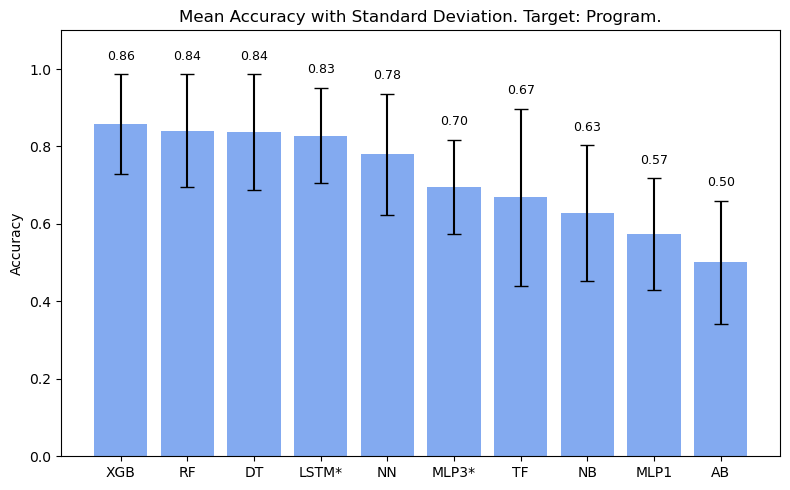

In [39]:
#Figure A experiment where target is program
import matplotlib.pyplot as plt

# Data
mean_scores = np.array([0.85749722, 0.84062546, 0.83675752, 0.8279562, 0.77938112, 0.69572728, 0.66859008, 0.62808279, 0.57419822, 0.50106818])
std_devs    = np.array([0.1291813,  0.14619444, 0.14953838, 0.12308032, 0.15659495, 0.12174692, 0.2283503, 0.17510606, 0.14414615, 0.15843958])

labels      = ['XGB', 'RF', 'DT', 'LSTM*', 'NN', 'MLP3*', 'TF','NB', 'MLP1','AB']
 
# Plot
plt.figure(figsize=(8, 5))
barlist = plt.bar(labels, mean_scores, yerr=std_devs, capsize=5, color='cornflowerblue', alpha=0.8)

plt.ylabel('Accuracy')
plt.title('Mean Accuracy with Standard Deviation. Target: Program.')
plt.ylim(0, 1.1)

# Optional: Add mean values above bars
for i, (mean, std) in enumerate(zip(mean_scores, std_devs)):
    plt.text(i, mean + std + 0.03, f"{mean:.2f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Get the indices that would sort mean_scores in descending order:
sorted_idx = np.argsort(mean_scores)[::-1]

# Reorder both arrays using these indices
mean_scores_sorted = mean_scores[sorted_idx]
std_devs_sorted = std_devs[sorted_idx]

print("Sorted mean_scores:", mean_scores_sorted)
print("Sorted std_devs:", std_devs_sorted)

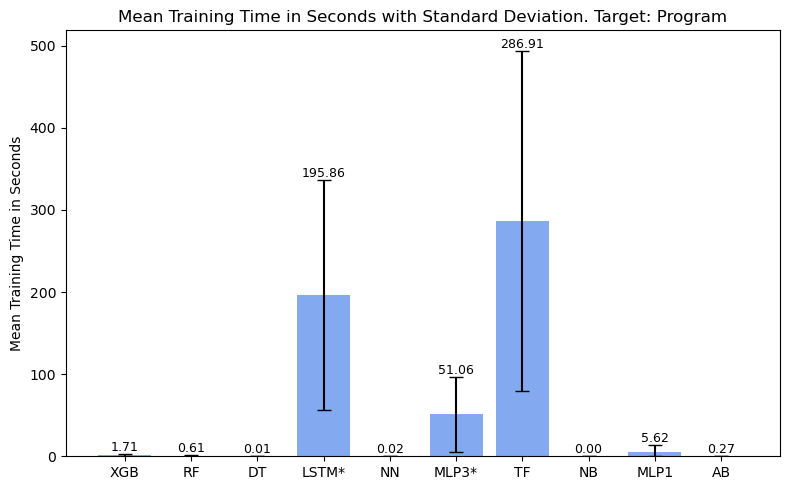

In [40]:
#Figure B experiment where target is program

# Original data
labels_original = ['NN', 'DT', 'RF', 'MLP1', 'AB', 'NB', 'XGB','MLP3*', 'LSTM*', 'TF']
mean_scores = np.array([2.16694398e-02, 1.49957527e-02, 6.10064086e-01, 5.61585779e+00,
                        2.74318062e-01, 3.71580557e-03, 1.71135361e+00, 51.06268379, 195.86135949, 286.91310817])
std_devs = np.array([1.61807223e-02, 1.40400548e-02, 5.28373221e-01, 7.52574847e+00,
                     2.04552501e-01, 2.50508166e-03, 7.91551358e-01, 45.91795438, 140.02560917, 206.96568726])

labels_reordered = ['XGB', 'RF', 'DT', 'LSTM*', 'NN', 'MLP3*', 'TF', 'NB','MLP1', 'AB']
reordered_indices = [labels_original.index(label) for label in labels_reordered]
mean_scores_reordered = mean_scores[reordered_indices]
std_devs_reordered = std_devs[reordered_indices]

# Clip lower error bars so they do not go below zero
lower_errors = np.minimum(std_devs_reordered, mean_scores_reordered)
upper_errors = std_devs_reordered
asymmetric_error = [lower_errors, upper_errors]

# Create the plot
plt.figure(figsize=(8, 5))
bars = plt.bar(
    labels_reordered, 
    mean_scores_reordered, 
    yerr=asymmetric_error, 
    capsize=5, 
    color='cornflowerblue', 
    alpha=0.8
)

plt.ylabel('Mean Training Time in Seconds')
#plt.xlabel('Classifier')
plt.title('Mean Training Time in Seconds with Standard Deviation. Target: Program')
plt.tight_layout()

# Optional: Add mean values above bars
for i, (mean, std) in enumerate(zip(mean_scores_reordered, std_devs_reordered)):
    plt.text(i, mean + std + 0.03, f"{mean:.2f}", ha='center', va='bottom', fontsize=9)

plt.show()

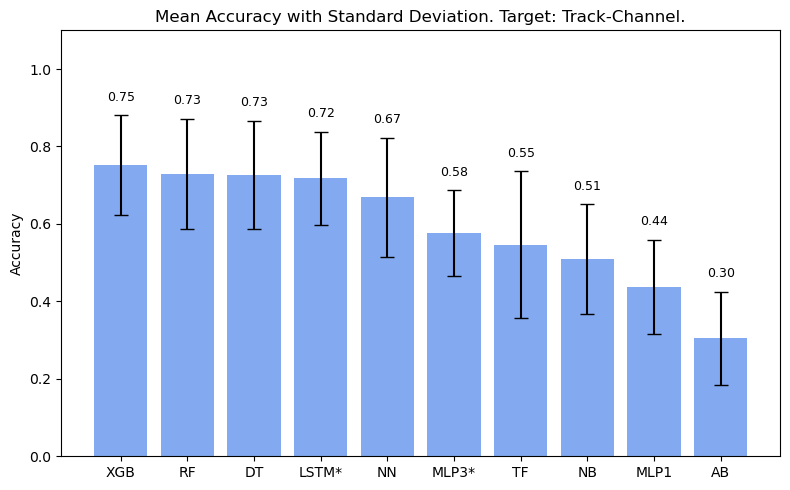

In [36]:
# Label track-channel
#import matplotlib.pyplot as plt
# Data
mean_scores = np.array([0.75193465, 0.72968071, 0.72669782, 0.71777955, 0.66855587, 0.57565103, 0.54681265, 0.50891586, 0.43693622,0.30442831])
std_devs    = np.array([0.12901675, 0.14193103, 0.13968821, 0.12052132, 0.15314119, 0.1112339, 0.18924503, 0.14228128, 0.1215712,0.11992709])

labels      = ['XGB', 'RF', 'DT', 'LSTM*', 'NN', 'MLP3*', 'TF','NB', 'MLP1','AB']
 
# Plot
plt.figure(figsize=(8, 5))
barlist = plt.bar(labels, mean_scores, yerr=std_devs, capsize=5, color='cornflowerblue', alpha=0.8)

plt.ylabel('Accuracy')
plt.title('Mean Accuracy with Standard Deviation. Target: Track-Channel.')
plt.ylim(0, 1.1)

# Optional: Add mean values above bars
for i, (mean, std) in enumerate(zip(mean_scores, std_devs)):
    plt.text(i, mean + std + 0.03, f"{mean:.2f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

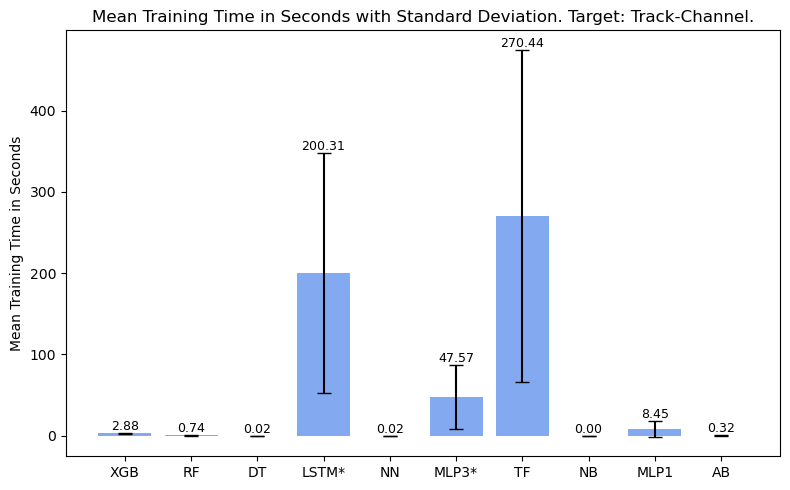

In [37]:
# Data
# Label track-channel
mean_scores = np.array([2.88489538, 0.73569909, 0.01826635, 200.30669141, 0.02163178, 47.56603344, 270.43653556,0.00469769, 8.44741656, 0.31929591])
std_devs    = np.array([1.08505008, 0.60630227, 0.01523722, 147.29767726, 0.01571734, 39.2657227, 204.34691128,0.00316092, 9.85332686, 0.23085323])

labels      = ['XGB', 'RF', 'DT', 'LSTM*', 'NN', 'MLP3*', 'TF','NB', 'MLP1','AB']
 
# Plot
plt.figure(figsize=(8, 5))
barlist = plt.bar(labels, mean_scores, yerr=std_devs, capsize=5, color='cornflowerblue', alpha=0.8)


plt.ylabel('Mean Training Time in Seconds')
plt.title('Mean Training Time in Seconds with Standard Deviation. Target: Track-Channel.')


# Optional: Add mean values above bars
for i, (mean, std) in enumerate(zip(mean_scores, std_devs)):
    plt.text(i, mean + std + 0.03, f"{mean:.2f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()